#### k-Means
- 대표적인 군집 알고리즘으로 군집의 중심(평균)을 찾는 작업 
- 클러스터(cluster) : 군집
- 클러스터링(custering) : 군집화 하는 작업
- k값이 hyper paramter 

In [1]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
fruits = np.load("../Data/fruits.npy")
fruits.shape

(300, 100, 100)

In [3]:
# 3차원 -> 2차원 데이터로 변경
fruits_2d = fruits.reshape(-1, 100*100)
fruits_2d.shape

(300, 10000)

#### k-Means Model

In [4]:
from sklearn.cluster import KMeans

In [5]:
km = KMeans(random_state=42, n_clusters=3)
km.fit(fruits_2d)

KMeans(n_clusters=3, random_state=42)

In [6]:
# 군집화한 Label 출력
km.labels_

array([2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [8]:
# 군집화하 Cluster 갯수과 각 cluster의 갯수 확인하기
np.unique(km.labels_, return_counts=True)

(array([0, 1, 2]), array([112,  98,  90], dtype=int64))

In [9]:
import matplotlib.pyplot as plt

In [10]:
# 시각화 함수
def draw_fruits(arr, ratio=1): # ratio:해상도 크기 
    n = len(arr) # n은 샘플 갯수 
    # 한줄에 10개씩 이미지를 그린다.
    rows = int(np.ceil(n/10)) # 올림처리 
    cols = n if rows < 2 else 10 # 행이 1개이면 열 갯수가 샘플갯쉬고 그렇지 않으면 10개 이다.
    _, axs = plt.subplots(
                        rows,
                        cols,
                        figsize=(cols*ratio, rows*ratio),
                        squeeze=False
                )
    for i in range(rows):
        for j in range(cols):
            if i*10+j < n:
                axs[i,j].imshow(arr[i*10+j], cmap='gray')
            axs[i,j].axis('off')
    plt.show()

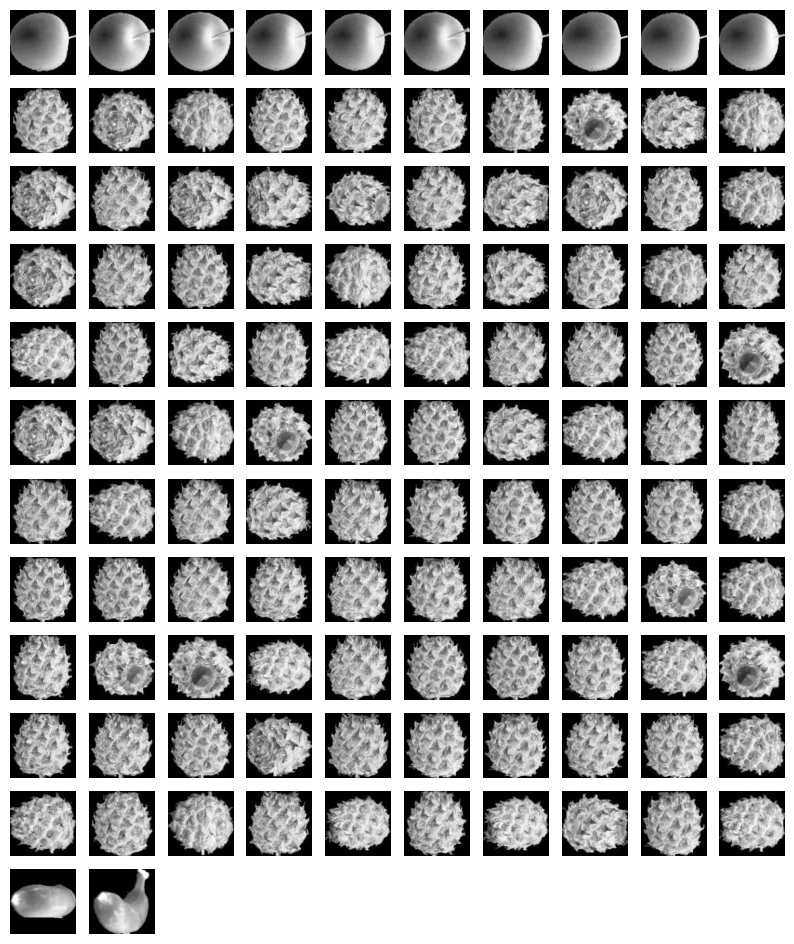

In [11]:
draw_fruits(fruits[km.labels_ == 0])

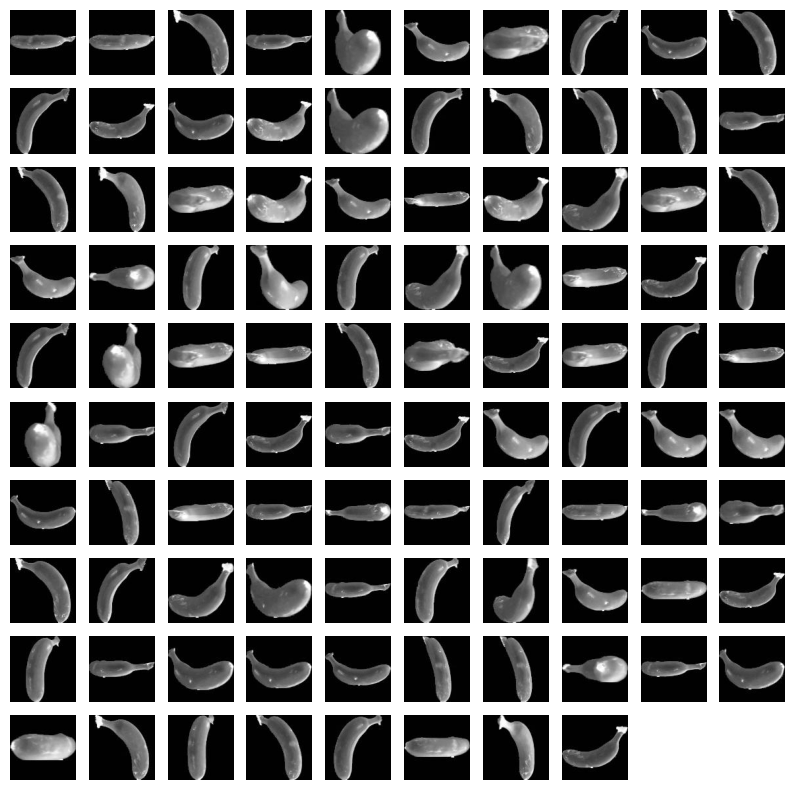

In [12]:
draw_fruits(fruits[km.labels_ == 1])

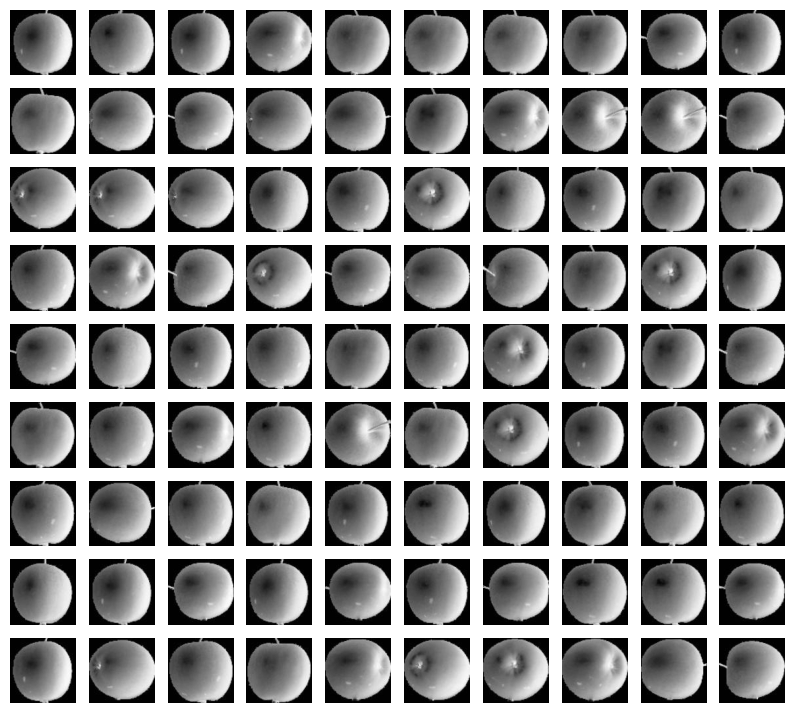

In [13]:
draw_fruits(fruits[km.labels_ == 2])

---
#### 클러스터 중심(평균)

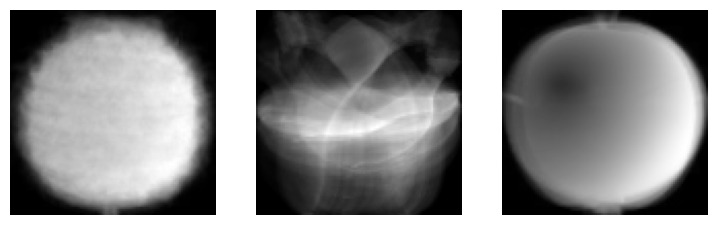

In [14]:
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=3)

---
#### 최적의 k 찾기
: k-Means에서는 k가 hyper parameter이므로 k값을 찾는 것이 중요하다.

##### Elbow Method(최적의 군집수 구하기)
: Cluster간의 거리의 합을 나타내는 관성구간이 급격히 떨어지는 포인트 찾기

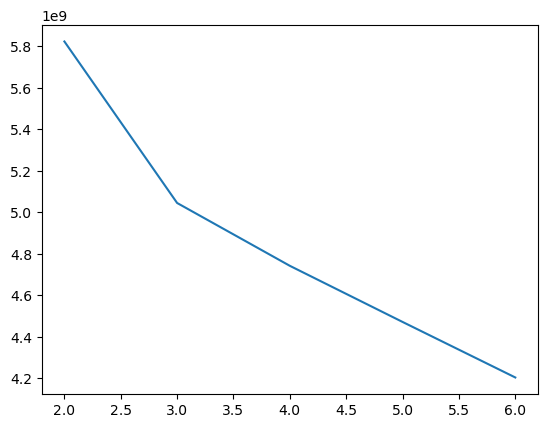

In [15]:
inertia = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(fruits_2d)
    inertia.append(km.inertia_)

plt.plot(
    range(2, 7),
    inertia
)
plt.show()